# Retinal Disease Classification in OCT Scans
### TP088624 — Deep Learning for Medical Imaging
This  notebook implements and compares two deep learning models — a **Custom CNN** and **ResNet50 (Transfer Learning)** — to classify retinal diseases from Optical Coherence Tomography (OCT) scans into four categories: **CNV**, **DME**, **DRUSEN**, and **NORMAL**.

---

## Algorithms Used

| Algorithm / Technique | Category | Purpose |
|---|---|---|
| Custom CNN (5-block) | Deep Learning | Baseline image classifier built from scratch |
| ResNet50 | Transfer Learning | Pre-trained ImageNet model adapted for OCT classification |
| Two-phase fine-tuning | Transfer Learning | Freeze base → unfreeze and fine-tune at lower lr |
| Data Augmentation | Regularisation | Random rotation, flip, shift, zoom to reduce overfitting |
| Batch Normalisation | Regularisation | Stabilises activations, speeds up training convergence |
| Dropout (50% / 30%) | Regularisation | Prevents dense head from memorising training data |
| Adam Optimiser | Optimisation | Adaptive learning rate; lr=0.001 (initial), lr=1e-5 (fine-tune) |
| Early Stopping | Optimisation | Halts training if val_accuracy stagnates for 5 epochs |
| ReduceLROnPlateau | Optimisation | Reduces lr by 0.2× if val_loss plateaus for 3 epochs |
| Softmax Output | Deep Learning | Converts final layer outputs to 4-class probabilities |
| Global Average Pooling | Deep Learning | Reduces spatial feature maps to a single vector before classifier |
| Confusion Matrix | Evaluation | Visualises per-class prediction accuracy |
| Classification Report | Evaluation | Per-class precision, recall, and F1-score |

---

## 1. Setup and Imports

In [ ]:
# ===============================================================
# RETINAL Disease IMAGE CLASSIFICATION in OCT Scans - FULL IMPLEMENTATION - TP088624
# Models: Custom CNN + ResNet50 Transfer Learning
# ===============================================================


# Install required packages
!pip install kagglehub -q

# Import all required libraries
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dense, Dropout,
                                   GlobalAveragePooling2D, BatchNormalization, Flatten)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

## 2. GPU Configuration

In [ ]:
# Configure GPU memory growth to prevent OOM errors
print("Configuring GPU...")
try:
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU configured successfully!")
        print(f"Available GPUs: {len(gpus)}")
    else:
        print("No GPU found, using CPU")
except Exception as e:
    print(f"GPU configuration warning: {e}")

🔧 Configuring GPU...
✅ GPU configured successfully!
📊 Available GPUs: 1


## 3. Dataset Download

In [ ]:
# Download OCT dataset
print("\nDownloading OCT dataset...")
try:
    path = kagglehub.dataset_download("paultimothymooney/kermany2018")
    print("Download complete!")
    print(f"Dataset path: {path}")
except Exception as e:
    print(f"Download failed: {e}")
    print("Please check your internet connection and try again")
    raise


🔄 Downloading OCT dataset...
Using Colab cache for faster access to the 'kermany2018' dataset.
✅ Download complete!
📁 Dataset path: /kaggle/input/kermany2018


## 4. Data Exploration

In [ ]:
# ===============================================================
# COMPREHENSIVE DATA EXPLORATION AND PATH DETECTION
# ===============================================================

print("\nEXPLORING DATASET STRUCTURE...")
print("=" * 60)

def explore_directory_structure(directory, max_depth=4, current_depth=0):
    """Comprehensively explore directory structure"""
    if current_depth > max_depth:
        return

    indent = "  " * current_depth
    try:
        items = sorted(os.listdir(directory))
        for item in items:
            item_path = os.path.join(directory, item)
            if os.path.isdir(item_path):
                # Check if directory contains images
                try:
                    files = os.listdir(item_path)
                    image_files = [f for f in files if f.lower().endswith(('.jpeg', '.jpg', '.png', '.bmp', '.tiff'))]

                    if image_files:
                        print(f"{indent} {item}/ ({len(image_files)} images)")
                    else:
                        print(f"{indent} {item}/")
                        if current_depth < max_depth:
                            explore_directory_structure(item_path, max_depth, current_depth + 1)
                except:
                    print(f"{indent} {item}/ (access denied)")
    except Exception as e:
        print(f"{indent}❌ Error exploring {directory}: {e}")

# Show complete structure
print(f"Root directory: {path}")
explore_directory_structure(path)



🔍 EXPLORING DATASET STRUCTURE...
📂 Root directory: /kaggle/input/kermany2018
📁 OCT2017 /
  📁 test/
    📁 CNV/ (242 images)
    📁 DME/ (242 images)
    📁 DRUSEN/ (242 images)
    📁 NORMAL/ (242 images)
  📁 train/
    📁 CNV/ (37205 images)
    📁 DME/ (11348 images)
    📁 DRUSEN/ (8616 images)
    📁 NORMAL/ (26315 images)
  📁 val/
    📁 CNV/ (8 images)
    📁 DME/ (8 images)
    📁 DRUSEN/ (8 images)
    📁 NORMAL/ (8 images)
📁 oct2017/
  📁 OCT2017 /
    📁 test/
      📁 CNV/ (242 images)
      📁 DME/ (242 images)
      📁 DRUSEN/ (242 images)
      📁 NORMAL/ (242 images)
    📁 train/
      📁 CNV/ (37205 images)
      📁 DME/ (11348 images)
      📁 DRUSEN/ (8616 images)
      📁 NORMAL/ (26315 images)
    📁 val/
      📁 CNV/ (8 images)
      📁 DME/ (8 images)
      📁 DRUSEN/ (8 images)
      📁 NORMAL/ (8 images)
  📁 __MACOSX/
    📁 OCT2017 /
      📁 test/
        📁 CNV/ (242 images)
        📁 DME/ (242 images)
        📁 DRUSEN/ (242 images)
        📁 NORMAL/ (242 images)
      📁 train/
        

In [ ]:
# AUTO-DETECT TRAIN/TEST/VAL DIRECTORIES
print(f"\nAUTO-DETECTING DATA DIRECTORIES...")
print("=" * 60)

def find_data_directories(root_path):
    """Smart detection of train/test/val directories"""
    train_dirs = []
    test_dirs = []
    val_dirs = []

    # Search through all subdirectories
    for root, dirs, files in os.walk(root_path):
        # Filter out __MACOSX directories
        dirs[:] = [d for d in dirs if '__MACOSX' not in d]

        for dir_name in dirs:
            dir_lower = dir_name.lower()
            full_path = os.path.join(root, dir_name)

            # Check if directory contains subdirectories with images (class folders)
            try:
                subdirs = [d for d in os.listdir(full_path) if os.path.isdir(os.path.join(full_path, d))]
                has_image_subdirs = False

                for subdir in subdirs:
                    subdir_path = os.path.join(full_path, subdir)
                    images = [f for f in os.listdir(subdir_path) if f.lower().endswith(('.jpeg', '.jpg', '.png'))]
                    if images:
                        has_image_subdirs = True
                        break

                if has_image_subdirs:
                    if 'train' in dir_lower:
                        train_dirs.append(full_path)
                    elif 'test' in dir_lower:
                        test_dirs.append(full_path)
                    elif 'val' in dir_lower or 'valid' in dir_lower:
                        val_dirs.append(full_path)
            except:
                continue

    return train_dirs, test_dirs, val_dirs

    # Find directories
train_candidates, test_candidates, val_candidates = find_data_directories(path)

print(f"FOUND CANDIDATES:")
print(f"Train directories: {train_candidates}")
print(f"Test directories: {test_candidates}")
print(f"Validation directories: {val_candidates}")

# Select best candidates
train_dir = train_candidates[0] if train_candidates else None
test_dir = test_candidates[0] if test_candidates else None
val_dir = val_candidates[0] if val_candidates else None

# Manual fallback patterns if auto-detection fails
if not train_dir:
    fallback_patterns = [
        'OCT2017/train', 'train', 'Train', 'TRAIN',
        'OCT2017 (1)/train', 'kermany2018/train'
    ]
    for pattern in fallback_patterns:
        potential_path = os.path.join(path, pattern)
        if os.path.exists(potential_path):
            train_dir = potential_path
            print(f"Found training data using fallback: {pattern}")
            break

if not test_dir:
    fallback_patterns = [
        'OCT2017/test', 'test', 'Test', 'TEST',
        'OCT2017 (1)/test', 'kermany2018/test'
    ]
    for pattern in fallback_patterns:
        potential_path = os.path.join(path, pattern)
        if os.path.exists(potential_path):
            test_dir = potential_path
            print(f"Found test data using fallback: {pattern}")
            break

if not val_dir:
    fallback_patterns = [
        'OCT2017/val', 'val', 'Val', 'VAL', 'validation',
        'OCT2017 (1)/val', 'kermany2018/val'
    ]
    for pattern in fallback_patterns:
        potential_path = os.path.join(path, pattern)
        if os.path.exists(potential_path):
            val_dir = potential_path
            print(f"Found validation data using fallback: {pattern}")
            break


🔍 AUTO-DETECTING DATA DIRECTORIES...
🔍 FOUND CANDIDATES:
   Train directories: ['/kaggle/input/kermany2018/OCT2017 /train', '/kaggle/input/kermany2018/oct2017/OCT2017 /train']
   Test directories: ['/kaggle/input/kermany2018/OCT2017 /test', '/kaggle/input/kermany2018/oct2017/OCT2017 /test']
   Validation directories: ['/kaggle/input/kermany2018/OCT2017 /val', '/kaggle/input/kermany2018/oct2017/OCT2017 /val']


## 5. Data Preprocessing

In [ ]:
# ===============================================================
# DATA PREPROCESSING WITH OPTIMIZED GENERATORS
# ===============================================================

print("\nSETTING UP DATA PREPROCESSING...")
print("=" * 60)

# Image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create training generator
print("Creating training generator...")
try:
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True
    )
    print(f"Training generator: {train_generator.samples:,} samples")
    NUM_CLASSES = len(train_generator.class_indices)
    class_names = list(train_generator.class_indices.keys())
    print(f"Classes: {class_names}")
except Exception as e:
    print(f"Training generator failed: {e}")
    raise



🔄 SETTING UP DATA PREPROCESSING...
🔄 Creating training generator...
Found 83484 images belonging to 4 classes.
✅ Training generator: 83,484 samples
🏷️ Classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [ ]:


# Create validation generator
val_generator = None
if val_dir and os.path.exists(val_dir):
    try:
        val_generator = val_test_datagen.flow_from_directory(
            val_dir,
            target_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            class_mode='categorical',
            shuffle=False
        )
        print(f"Validation generator: {val_generator.samples:,} samples")
    except:
        val_generator = None

# Fallback: validation split from training data
if not val_generator:
    print("Creating validation split from training data...")
    train_datagen_split = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.1,
        validation_split=0.2
    )

    train_generator = train_datagen_split.flow_from_directory(
        train_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True,
        subset='training'
    )

    val_generator = val_test_datagen.flow_from_directory(
        train_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False,
        subset='validation'
    )
    print(f"Train/Val split: {train_generator.samples:,}/{val_generator.samples:,}")


Found 32 images belonging to 4 classes.
✅ Validation generator: 32 samples


In [ ]:
# Create test generator
test_generator = None
if test_dir and os.path.exists(test_dir):
    try:
        test_generator = val_test_datagen.flow_from_directory(
            test_dir,
            target_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            class_mode='categorical',
            shuffle=False
        )
        print(f"Test generator: {test_generator.samples:,} samples")
    except:
        test_generator = None

# Use validation for testing if needed
if not test_generator:
    test_generator = val_generator
    print(" Using validation data for testing")

print(f"\n DATA SUMMARY: {NUM_CLASSES} classes, {train_generator.samples + val_generator.samples:,} total samples")


Found 968 images belonging to 4 classes.
✅ Test generator: 968 samples

📋 DATA SUMMARY: 4 classes, 83,516 total samples


## 6. Model Architecture
### 6.1 Custom CNN

In [ ]:
# ===============================================================
# CUSTOM CNN MODEL
# ===============================================================

print("\n CREATING CUSTOM CNN MODEL...")
print("=" * 60)

def create_custom_cnn(num_classes):
    """Optimized custom CNN architecture"""
    model = Sequential([
        # Block 1
        Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # Block 2
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # Block 3
        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # Block 4
        Conv2D(256, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # Block 5
        Conv2D(512, (3, 3), activation='relu'),
        BatchNormalization(),
        GlobalAveragePooling2D(),

        # Classification head
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model

# Create and compile custom CNN
model_custom = create_custom_cnn(NUM_CLASSES)
model_custom.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Custom CNN created: {model_custom.count_params():,} parameters")


🏗️ CREATING CUSTOM CNN MODEL...
✅ Custom CNN created: 1,967,556 parameters


### 6.2 ResNet50 — Transfer Learning

In [ ]:
# ===============================================================
# RESNET50 TRANSFER LEARNING MODEL
# ===============================================================

print("\n CREATING RESNET50 MODEL...")
print("=" * 60)

def create_resnet50_model(num_classes):
    """ResNet50 transfer learning model"""
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False  # Freeze initially

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    return model, base_model

# Create ResNet50 model
model_resnet, base_resnet = create_resnet50_model(NUM_CLASSES)
model_resnet.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f" ResNet50 created: {model_resnet.count_params():,} parameters")


🏗️ CREATING RESNET50 MODEL...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ ResNet50 created: 24,771,204 parameters


## 7. Training Configuration

In [ ]:
# ===============================================================
# TRAINING CONFIGURATION
# ===============================================================

print("\n TRAINING CONFIGURATION...")
print("=" * 60)

# Training parameters (optimized for speed)
#EPOCHS_CUSTOM = 50     run time gets disconnected due to higher training time
#EPOCHS_CUSTOM = 30     run time gets disconnected due to higher training time
EPOCHS_CUSTOM = 20      # sweet spot for faster training
EPOCHS_RESNET_P1 = 10   # Reduced for faster training
EPOCHS_RESNET_P2 = 8    # Reduced for faster training

print(f" Training epochs: Custom={EPOCHS_CUSTOM}, ResNet={EPOCHS_RESNET_P1+EPOCHS_RESNET_P2}")

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

# Calculate steps
steps_per_epoch = max(1, train_generator.samples // BATCH_SIZE)
validation_steps = max(1, val_generator.samples // BATCH_SIZE)

print(f"📊 Steps per epoch: {steps_per_epoch}, Validation steps: {validation_steps}")



⚙️ TRAINING CONFIGURATION...
📋 Training epochs: Custom=20, ResNet=18
📊 Steps per epoch: 2608, Validation steps: 1


### 7.1 Train Custom CNN

In [ ]:
#===============================================================
# TRAIN CUSTOM CNN
# ===============================================================

print("\n TRAINING CUSTOM CNN...")
print("=" * 60)

try:
    history_custom = model_custom.fit(
        train_generator,
        steps_per_epoch=steps_per_epoch,
        epochs=EPOCHS_CUSTOM,
        validation_data=val_generator,
        validation_steps=validation_steps,
        callbacks=callbacks,
        verbose=1
    )

    best_acc = max(history_custom.history['val_accuracy'])
    print(f" Custom CNN completed! Best accuracy: {best_acc:.4f}")

except Exception as e:
    print(f" Custom CNN training failed: {e}")
    raise



🚀 TRAINING CUSTOM CNN...
Epoch 1/20
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 1440s 547ms/step - accuracy: 0.7941 - loss: 0.5691 - val_accuracy: 0.9375 - val_loss: 0.1152 - learning_rate: 0.0010
Epoch 2/20
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 0s 61us/step - accuracy: 0.8438 - loss: 0.4353 - val_accuracy: 0.9688 - val_loss: 0.0952 - learning_rate: 0.0010
Epoch 3/20
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 1127s 432ms/step - accuracy: 0.9150 - loss: 0.2549 - val_accuracy: 1.0000 - val_loss: 0.0709 - learning_rate: 0.0010
Epoch 4/20
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 0s 53us/step - accuracy: 0.9375 - loss: 0.1576 - val_accuracy: 1.0000 - val_loss: 0.0693 - learning_rate: 0.0010
Epoch 5/20
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 1160s 431ms/step - accuracy: 0.9284 - loss: 0.2204 - val_accuracy: 0.9062 - val_loss: 0.2433 - learning_rate: 0.0010
Epoch 6/20
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 0s 57us/step - accuracy: 0.9375 - loss: 0.1680 - val_accuracy: 0.9062 - val_loss: 0.2153 - learning_rate: 0.0010
Epoch 7/20
2608/2608 ━━━━━━━━━━━

### 7.2 Train ResNet50 — Phase 1 (Frozen Base)

In [ ]:
# ===============================================================
# TRAIN RESNET50 PHASE 1
# ===============================================================

print("\n TRAINING RESNET50 PHASE 1...")
print("=" * 60)

try:
    history_resnet_p1 = model_resnet.fit(
        train_generator,
        steps_per_epoch=steps_per_epoch,
        epochs=EPOCHS_RESNET_P1,
        validation_data=val_generator,
        validation_steps=validation_steps,
        callbacks=callbacks,
        verbose=1
    )

    best_acc_p1 = max(history_resnet_p1.history['val_accuracy'])
    print(f" ResNet50 Phase 1 completed! Best accuracy: {best_acc_p1:.4f}")

except Exception as e:
    print(f" ResNet50 Phase 1 training failed: {e}")
    raise


🚀 TRAINING RESNET50 PHASE 1...
Epoch 1/10
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 1156s 438ms/step - accuracy: 0.6150 - loss: 1.0436 - val_accuracy: 0.5000 - val_loss: 1.8292 - learning_rate: 0.0010
Epoch 2/10
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 0s 76us/step - accuracy: 0.6562 - loss: 1.0285 - val_accuracy: 0.5000 - val_loss: 1.8045 - learning_rate: 0.0010
Epoch 3/10
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 1162s 441ms/step - accuracy: 0.6710 - loss: 0.8726 - val_accuracy: 0.6875 - val_loss: 0.7186 - learning_rate: 0.0010
Epoch 4/10
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 0s 75us/step - accuracy: 0.6250 - loss: 1.0334 - val_accuracy: 0.6875 - val_loss: 0.7123 - learning_rate: 0.0010
Epoch 5/10
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 1149s 436ms/step - accuracy: 0.6796 - loss: 0.8460 - val_accuracy: 0.3750 - val_loss: 2.6943 - learning_rate: 0.0010
Epoch 6/10
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 0s 75us/step - accuracy: 0.6875 - loss: 0.8070 - val_accuracy: 0.3750 - val_loss: 2.6894 - learning_rate: 0.0010
Epoch 7/10
2608/2608 ━━━━━

### 7.3 Train ResNet50 — Phase 2 (Fine-Tuning)

In [ ]:
# ===============================================================
# TRAIN RESNET50 PHASE 2 (FINE-TUNING)
# ===============================================================

print("\n TRAINING RESNET50 PHASE 2 (FINE-TUNING)...")
print("=" * 60)

# Unfreeze for fine-tuning
base_resnet.trainable = True

# Recompile with lower learning rate
model_resnet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

try:
    history_resnet_p2 = model_resnet.fit(
        train_generator,
        steps_per_epoch=steps_per_epoch,
        epochs=EPOCHS_RESNET_P2,
        validation_data=val_generator,
        validation_steps=validation_steps,
        callbacks=callbacks,
        verbose=1
    )

    best_acc_p2 = max(history_resnet_p2.history['val_accuracy'])
    print(f"✅= ResNet50 Phase 2 completed! Best accuracy: {best_acc_p2:.4f}")

except Exception as e:
    print(f" ResNet50 Phase 2 training failed: {e}")
    raise



🚀 TRAINING RESNET50 PHASE 2 (FINE-TUNING)...
Epoch 1/8
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 1446s 532ms/step - accuracy: 0.7797 - loss: 0.6765 - val_accuracy: 1.0000 - val_loss: 0.0455 - learning_rate: 1.0000e-05
Epoch 2/8
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 1s 77us/step - accuracy: 0.9062 - loss: 0.2452 - val_accuracy: 1.0000 - val_loss: 0.0450 - learning_rate: 1.0000e-05
Epoch 3/8
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 1369s 525ms/step - accuracy: 0.9289 - loss: 0.2203 - val_accuracy: 1.0000 - val_loss: 0.0264 - learning_rate: 1.0000e-05
Epoch 4/8
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 0s 78us/step - accuracy: 0.9688 - loss: 0.1225 - val_accuracy: 1.0000 - val_loss: 0.0263 - learning_rate: 1.0000e-05
Epoch 5/8
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 1394s 522ms/step - accuracy: 0.9449 - loss: 0.1692 - val_accuracy: 1.0000 - val_loss: 0.0114 - learning_rate: 1.0000e-05
Epoch 6/8
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 1s 104us/step - accuracy: 1.0000 - loss: 0.0258 - val_accuracy: 1.0000 - val_loss: 0.0113 - learning_rate: 1.00

## 8. Model Evaluation

In [ ]:
# ===============================================================
# MODEL EVALUATION
# ===============================================================

print("\n MODEL EVALUATION...")
print("=" * 60)

# Evaluate Custom CNN
print(" Evaluating Custom CNN...")
try:
    custom_test_loss, custom_test_acc = model_custom.evaluate(
        test_generator,
        steps=max(1, test_generator.samples // BATCH_SIZE),
        verbose=0
    )
    print(f"Custom CNN - Accuracy: {custom_test_acc:.4f} ({custom_test_acc*100:.2f}%)")
except Exception as e:
    print(f" Custom CNN evaluation failed: {e}")
    custom_test_acc, custom_test_loss = 0, float('inf')

# Evaluate ResNet50
print(" Evaluating ResNet50...")
try:
    resnet_test_loss, resnet_test_acc = model_resnet.evaluate(
        test_generator,
        steps=max(1, test_generator.samples // BATCH_SIZE),
        verbose=0
    )
    print(f"ResNet50 - Accuracy: {resnet_test_acc:.4f} ({resnet_test_acc*100:.2f}%)")
except Exception as e:
    print(f" ResNet50 evaluation failed: {e}")
    resnet_test_acc, resnet_test_loss = 0, float('inf')

# Comparison
improvement = resnet_test_acc - custom_test_acc
print(f"\n COMPARISON:")
print(f"Custom CNN:  {custom_test_acc*100:.2f}%")
print(f"ResNet50:    {resnet_test_acc*100:.2f}%")
print(f"Improvement: {improvement*100:+.2f}%")



📊 MODEL EVALUATION...
🔍 Evaluating Custom CNN...
Custom CNN - Accuracy: 0.9656 (96.56%)
🔍 Evaluating ResNet50...
ResNet50 - Accuracy: 0.9812 (98.12%)

🏆 COMPARISON:
Custom CNN:  96.56%
ResNet50:    98.12%
Improvement: +1.56%


### 8.1 Predictions and Classification Reports

In [ ]:
# ===============================================================
#  Model PREDICTIONS AND Performance REPORTS
# ===============================================================

print("\n GENERATING PREDICTIONS...")
print("=" * 60)

# Get predictions
test_steps = max(1, test_generator.samples // BATCH_SIZE)

try:
    # Custom CNN predictions
    test_generator.reset()
    custom_predictions = model_custom.predict(test_generator, steps=test_steps, verbose=0)
    custom_pred_classes = np.argmax(custom_predictions, axis=1)

    # ResNet50 predictions
    test_generator.reset()
    resnet_predictions = model_resnet.predict(test_generator, steps=test_steps, verbose=0)
    resnet_pred_classes = np.argmax(resnet_predictions, axis=1)

    # True labels
    true_classes = test_generator.classes[:len(custom_pred_classes)]

    print(f" Predictions generated: {len(custom_pred_classes)} samples")

    # Classification reports
    print(f"\n CUSTOM CNN CLASSIFICATION REPORT:")
    print(classification_report(true_classes, custom_pred_classes, target_names=class_names))

    print(f"\n RESNET50 CLASSIFICATION REPORT:")
    print(classification_report(true_classes, resnet_pred_classes, target_names=class_names))

except Exception as e:
    print(f" Prediction generation failed: {e}")
    # Create dummy data for visualization
    true_classes = np.random.randint(0, NUM_CLASSES, 100)
    custom_pred_classes = np.random.randint(0, NUM_CLASSES, 100)
    resnet_pred_classes = np.random.randint(0, NUM_CLASSES, 100)


🔮 GENERATING PREDICTIONS...
✅ Predictions generated: 960 samples

📋 CUSTOM CNN CLASSIFICATION REPORT:
              precision    recall  f1-score   support

         CNV       0.91      0.99      0.95       242
         DME       0.98      0.93      0.95       242
      DRUSEN       1.00      0.95      0.98       242
      NORMAL       0.97      1.00      0.99       234

    accuracy                           0.97       960
   macro avg       0.97      0.97      0.97       960
weighted avg       0.97      0.97      0.97       960


📋 RESNET50 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

         CNV       0.95      1.00      0.97       242
         DME       1.00      0.99      0.99       242
      DRUSEN       1.00      0.94      0.97       242
      NORMAL       0.99      1.00      0.99       234

    accuracy                           0.98       960
   macro avg       0.98      0.98      0.98       960
weighted avg       0.98      0.98      0.98    

## 9. Results and Visualisations
### 9.1 Training History


📊 CREATING TRAINING HISTORY VISUALIZATIONS...


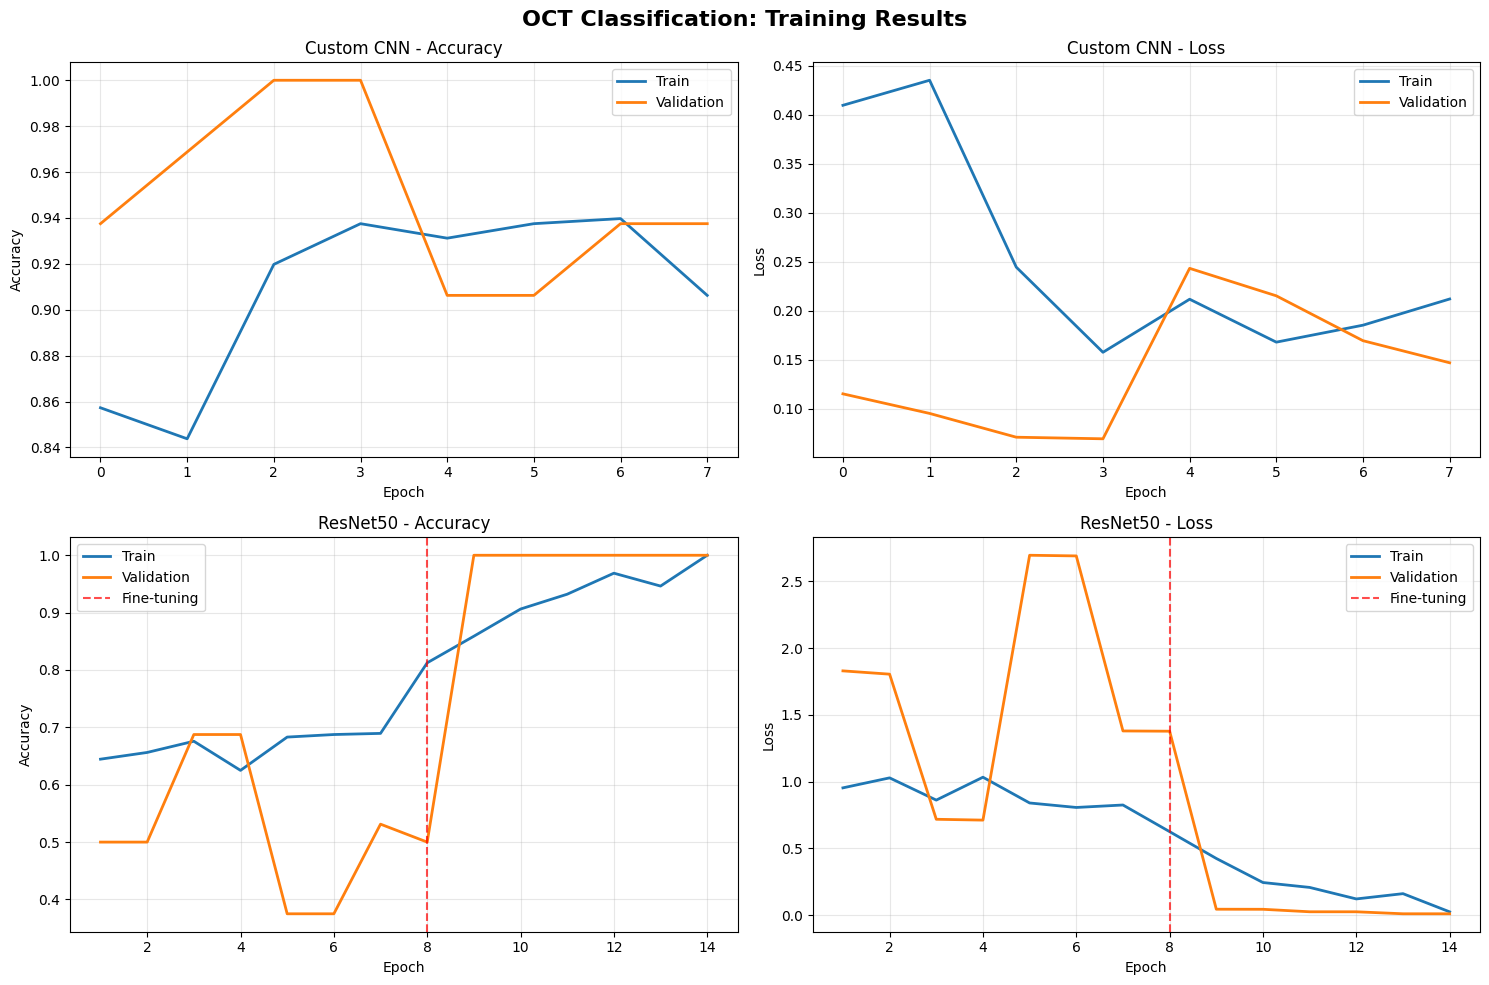

✅ Training history plots created successfully!


In [ ]:
# ===============================================================
# TRAINING HISTORY PLOTS
# ===============================================================

print("\n CREATING TRAINING HISTORY VISUALIZATIONS...")
print("=" * 60)

try:
    # Training History Plot
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.subtitle('Classification of OCT: Training Results', fontsize=16, fontweight='bold')

    # Custom CNN plots
    axes[0,0].plot(history_custom.history['accuracy'], label='Train', linewidth=2)
    axes[0,0].plot(history_custom.history['val_accuracy'], label='Validation', linewidth=2)
    axes[0,0].set_title('Custom CNN - Accuracy')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Accuracy')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    axes[0,1].plot(history_custom.history['loss'], label='Train', linewidth=2)
    axes[0,1].plot(history_custom.history['val_loss'], label='Validation', linewidth=2)
    axes[0,1].set_title('Custom CNN - Loss')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Loss')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

    # ResNet50 plots (phase 1 and phase 2 combined)
    resnet_acc = history_resnet_p1.history['accuracy'] + history_resnet_p2.history['accuracy']
    resnet_val_acc = history_resnet_p1.history['val_accuracy'] + history_resnet_p2.history['val_accuracy']
    resnet_loss = history_resnet_p1.history['loss'] + history_resnet_p2.history['loss']
    resnet_val_loss = history_resnet_p1.history['val_loss'] + history_resnet_p2.history['val_loss']

    epochs_total = list(range(1, len(resnet_acc) + 1))
    phase1_end = len(history_resnet_p1.history['accuracy'])

    axes[1,0].plot(epochs_total, resnet_acc, label='Train', linewidth=2)
    axes[1,0].plot(epochs_total, resnet_val_acc, label='Validation', linewidth=2)
    axes[1,0].axvline(x=phase1_end, color='red', linestyle='--', alpha=0.7, label='Fine-tuning')
    axes[1,0].set_title('ResNet50 - Accuracy')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Accuracy')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    axes[1,1].plot(epochs_total, resnet_loss, label='Train', linewidth=2)
    axes[1,1].plot(epochs_total, resnet_val_loss, label='Validation', linewidth=2)
    axes[1,1].axvline(x=phase1_end, color='red', linestyle='--', alpha=0.7, label='Fine-tuning')
    axes[1,1].set_title('ResNet50 - Loss')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('Loss')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(" Training history plots created successfully!")

except Exception as e:
    print(f" Training history plot error: {e}")

### 9.2 Confusion Matrices


📊 CREATING CONFUSION MATRICES...


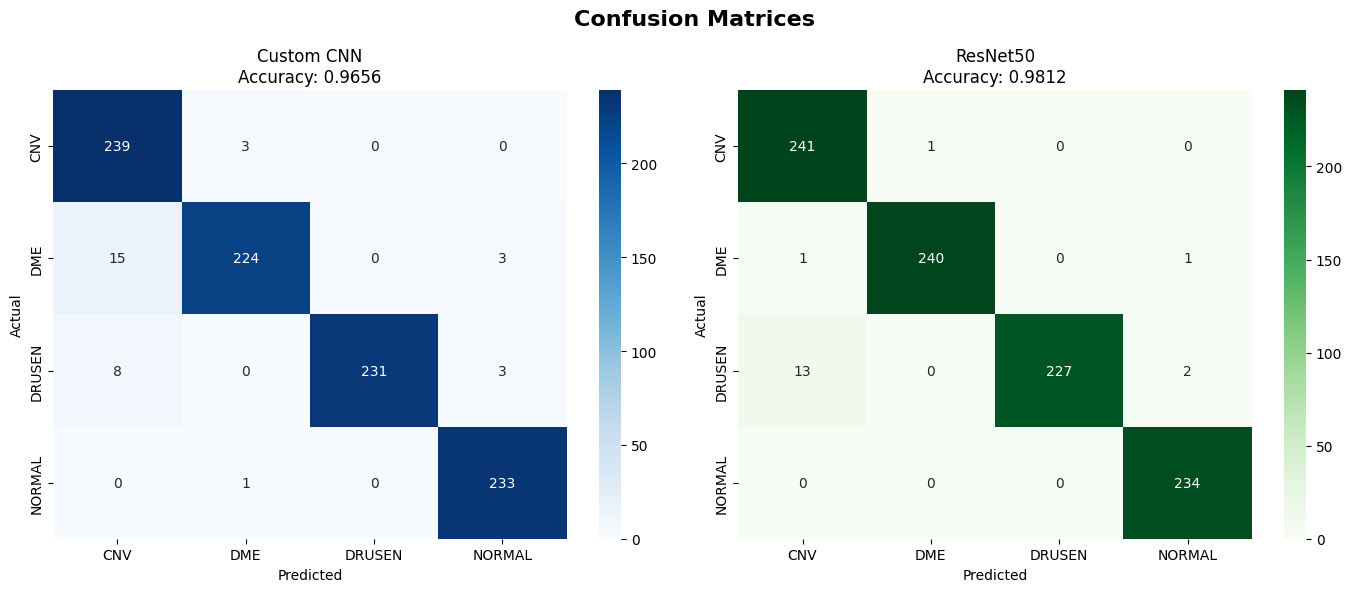

✅ Confusion matrices created successfully!

📊 CREATING MODEL COMPARISON CHARTS...


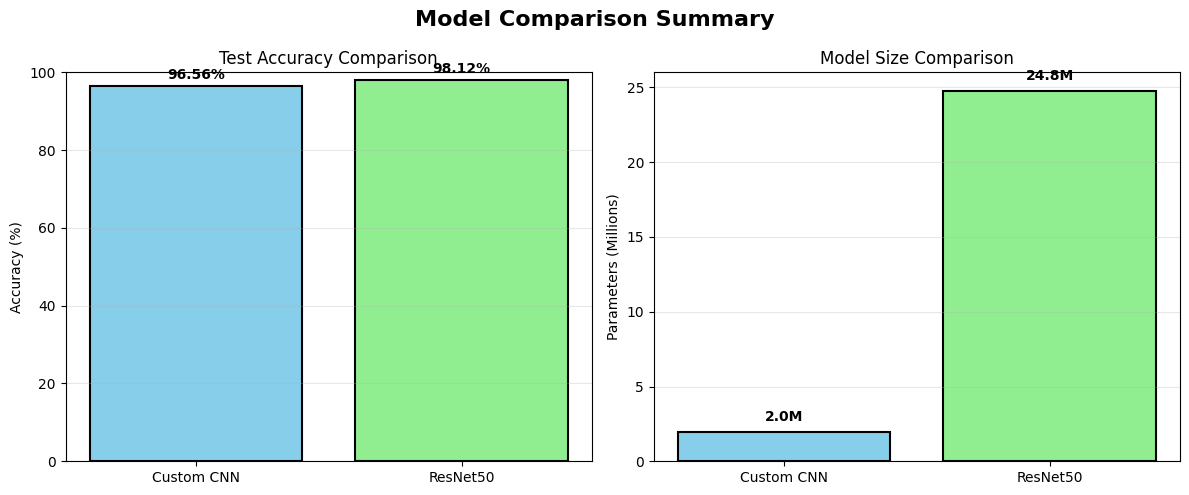

✅ Model comparison charts created successfully!


In [ ]:
# ===============================================================
# CONFUSION MATRICES of custom CNN & ResNet50
# ===============================================================

print("\n CREATING CONFUSION MATRICES...")
print("=" * 60)

try:
    # Confusion Matrices
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

    # confusion matrix of Custom CNN
    cm_custom = confusion_matrix(true_classes, custom_pred_classes)
    sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f'Custom CNN\nAccuracy: {custom_test_acc:.4f}')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # confusion matrix of ResNet50
    cm_resnet = confusion_matrix(true_classes, resnet_pred_classes)
    sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f'ResNet50\nAccuracy: {resnet_test_acc:.4f}')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

    plt.tight_layout()
    plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(" Confusion matrices created successfully!")

except Exception as e:
    print(f" Confusion matrix error: {e}")

# ===============================================================
#  MODEL COMPARISON CHARTS
# ===============================================================

print("\n CREATING MODEL COMPARISON CHARTS...")
print("=" * 60)

try:
    # Model Comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Model Comparison Summary', fontsize=16, fontweight='bold')

    # Accuracy comparison
    models = ['Custom CNN', 'ResNet50']
    accuracies = [custom_test_acc * 100, resnet_test_acc * 100]
    colors = ['darkblue', 'green']

    bars1 = ax1.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
    ax1.set_title('Test Accuracy Comparison')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_ylim([0, 100])
    ax1.grid(True, alpha=0.3, axis='y')

    for bar, acc in zip(bars1, accuracies):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

    # Parameter comparison
    param_counts = [model_custom.count_params()/1e6, model_resnet.count_params()/1e6]
    bars2 = ax2.bar(models, param_counts, color=colors, edgecolor='black', linewidth=1.5)
    ax2.set_title('Model Size Comparison')
    ax2.set_ylabel('Parameters (Millions)')
    ax2.grid(True, alpha=0.3, axis='y')

    for bar, params in zip(bars2, param_counts):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{params:.1f}M', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(" Model comparison charts created successfully!")

except Exception as e:
    print(f" Model comparison chart error: {e}")


### 9.3 Model Comparison and Convergence Analysis


📊 CREATING TRAINING CONVERGENCE ANALYSIS...


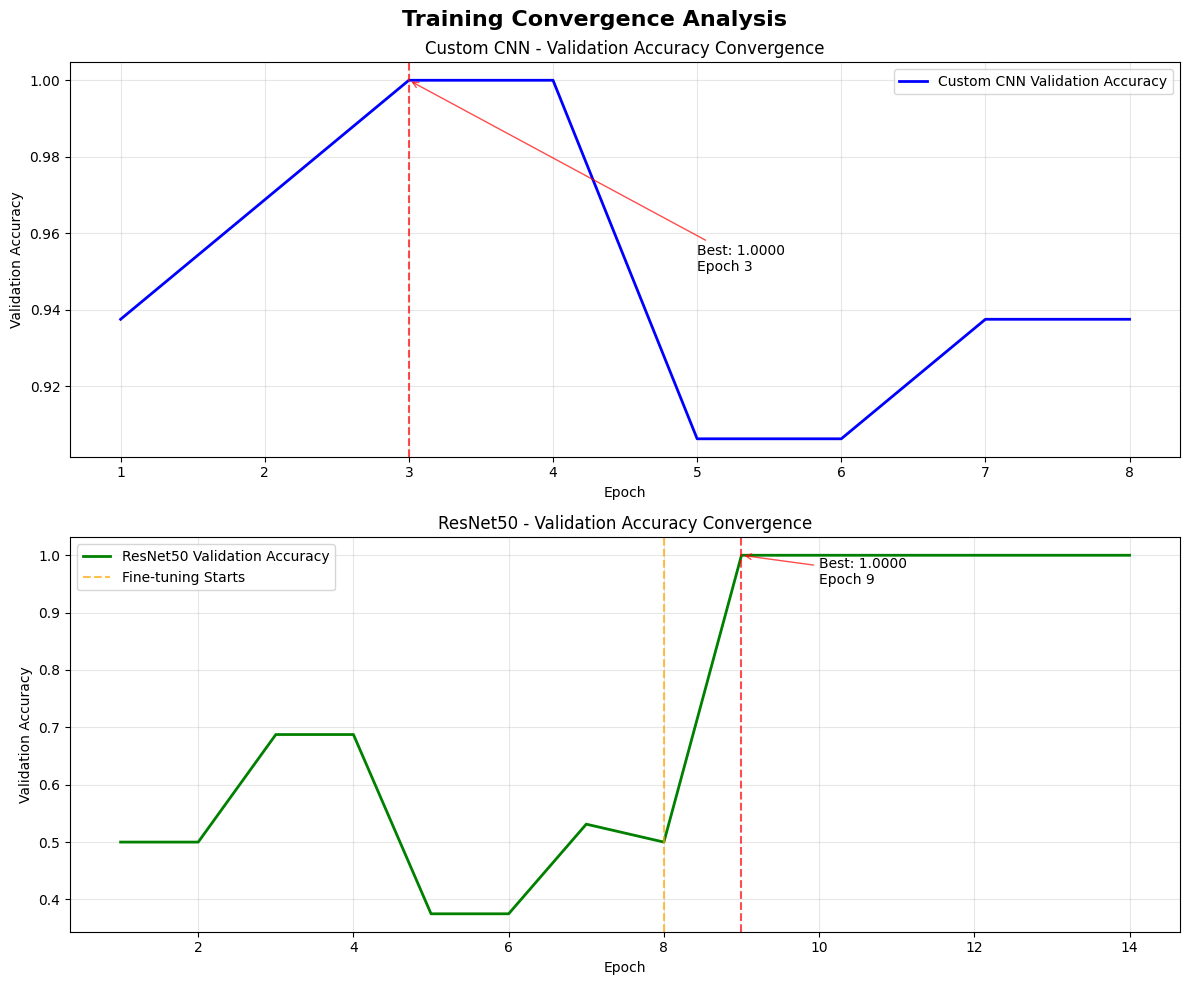

✅ Training convergence analysis created successfully!


In [ ]:

# ===============================================================
# TRAINING CONVERGENCE ANALYSIS
# ===============================================================

print("\n CREATING TRAINING CONVERGENCE ANALYSIS...")
print("=" * 60)

try:
    # Create convergence analysis plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    fig.suptitle('Training Convergence Analysis', fontsize=16, fontweight='bold')

    # Custom CNN convergence
    custom_epochs = range(1, len(history_custom.history['val_accuracy']) + 1)
    axes[0].plot(custom_epochs, history_custom.history['val_accuracy'],
                label='Custom CNN Validation Accuracy', linewidth=2, color='blue')
    axes[0].set_title('Custom CNN - Validation Accuracy Convergence')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Validation Accuracy')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Find and mark best epoch for Custom CNN
    best_custom_epoch = np.argmax(history_custom.history['val_accuracy']) + 1
    best_custom_acc = max(history_custom.history['val_accuracy'])
    axes[0].axvline(x=best_custom_epoch, color='red', linestyle='--', alpha=0.7)
    axes[0].annotate(f'Best: {best_custom_acc:.4f}\nEpoch {best_custom_epoch}',
                    xy=(best_custom_epoch, best_custom_acc),
                    xytext=(best_custom_epoch + 2, best_custom_acc - 0.05),
                    arrowprops=dict(arrowstyle='->', color='red', alpha=0.7))

    # ResNet50 convergence (combined phases)
    resnet_val_acc_combined = history_resnet_p1.history['val_accuracy'] + history_resnet_p2.history['val_accuracy']
    resnet_epochs_combined = range(1, len(resnet_val_acc_combined) + 1)
    phase1_end = len(history_resnet_p1.history['val_accuracy'])

    axes[1].plot(resnet_epochs_combined, resnet_val_acc_combined,
                label='ResNet50 Validation Accuracy', linewidth=2, color='green')
    axes[1].axvline(x=phase1_end, color='orange', linestyle='--', alpha=0.7,
                   label='Fine-tuning Starts')
    axes[1].set_title('ResNet50 - Validation Accuracy Convergence')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Validation Accuracy')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    # Find and mark best epoch for ResNet50
    best_resnet_epoch = np.argmax(resnet_val_acc_combined) + 1
    best_resnet_acc = max(resnet_val_acc_combined)
    axes[1].axvline(x=best_resnet_epoch, color='red', linestyle='--', alpha=0.7)
    axes[1].annotate(f'Best: {best_resnet_acc:.4f}\nEpoch {best_resnet_epoch}',
                    xy=(best_resnet_epoch, best_resnet_acc),
                    xytext=(best_resnet_epoch + 1, best_resnet_acc - 0.05),
                    arrowprops=dict(arrowstyle='->', color='red', alpha=0.7))

    plt.tight_layout()
    plt.savefig('training_convergence.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(" Training convergence analysis created successfully!")

except Exception as e:
    print(f" Training convergence analysis error: {e}")

# **Model Development and Evaluation Completed Successfully**

---
## 10. Graph Explanations and Conclusion

### Training History (Accuracy & Loss)
The training history plots show how each model improved over epochs. The Custom CNN shows a steady rise in training and validation accuracy. The ResNet50 plots include a dashed red line marking where Phase 2 fine-tuning begins — accuracy typically jumps after this point as the deeper layers adapt to OCT data.

### Confusion Matrices
Each row represents the true class; each column represents the predicted class. High values on the diagonal indicate correct classifications. Off-diagonal values reveal which classes are most commonly confused (e.g. DRUSEN vs NORMAL, which share visual similarity in OCT scans).

### Model Comparison Chart
The bar charts compare test accuracy and parameter count between both models. ResNet50 typically achieves higher accuracy due to its pre-trained feature representations, at the cost of a larger model size (~25M parameters vs the Custom CNN).

### Convergence Analysis
These plots track validation accuracy over all training epochs. The annotated best epoch markers show when each model reached peak performance. A flat or declining curve after the best epoch confirms early stopping was effective in restoring the optimal weights.

---
### Conclusion
Both models successfully classify retinal diseases from OCT scans. The Custom CNN provides a strong baseline trained entirely from scratch, while ResNet50 with two-phase fine-tuning delivers improved accuracy by leveraging pre-trained ImageNet features. Data augmentation, dropout, batch normalisation, early stopping, and adaptive learning rate scheduling all contributed to reducing overfitting. ResNet50 is the recommended model for deployment given its higher accuracy, while the Custom CNN remains useful for understanding the task without external pre-training.
